In [8]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

In [3]:
df_DA_IN = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst') ]

<Axes: xlabel='count', ylabel='job_location'>

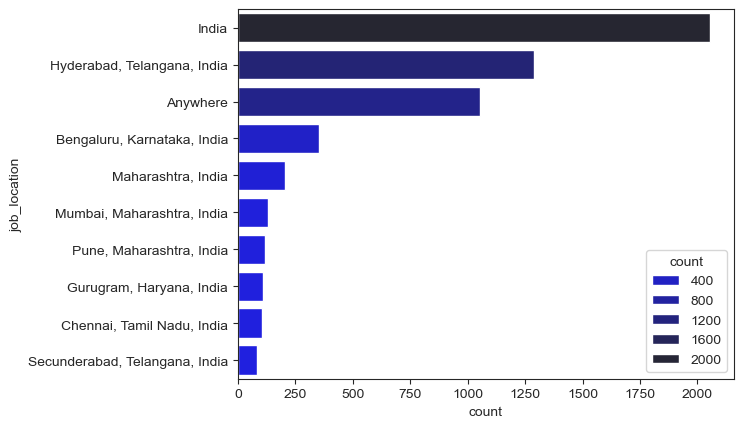

In [12]:
df_plot = df_DA_IN['job_location'].value_counts().head(10).to_frame()

sns.set_style('ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r')

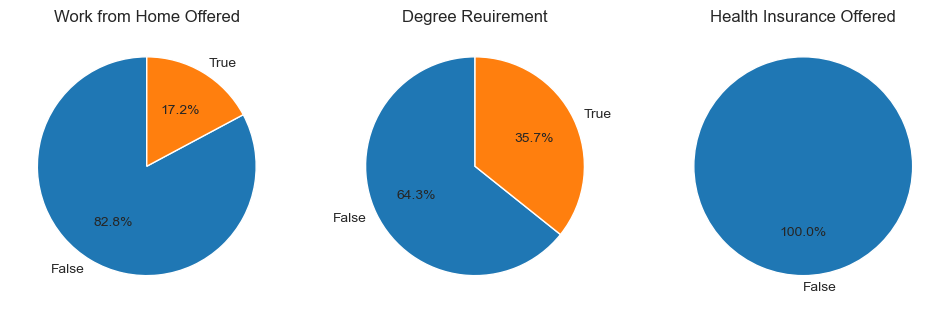

In [22]:
dict_column = {
    'job_work_from_home' : 'Work from Home Offered',
    'job_no_degree_mention' : 'Degree Reuirement', 
    'job_health_insurance' : 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(12, 5)

for i, (column, title) in enumerate(dict_column.items()):
    count = df_DA_IN[column].value_counts()
    ax[i].pie(count, labels=count.index, autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

# df_DA_IN['job_health_insurance']

<Axes: xlabel='count', ylabel='company_name'>

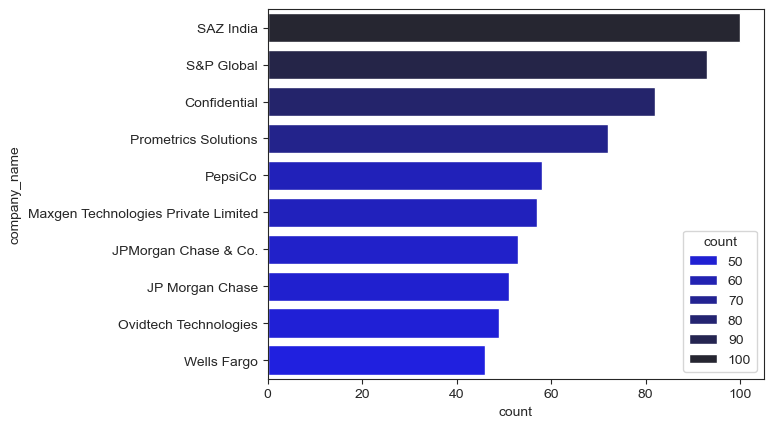

In [23]:

df_plot = df_DA_IN['company_name'].value_counts().head(10).to_frame()

sns.set_style('ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r')